# Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, learning_curve, GridSearchCV
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import make_pipeline
from imblearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin




# Leitura da Base

In [2]:
#df = pd.read_csv("base_princ_modificado.csv")

In [3]:
df = pd.read_csv("base_processada_enriquecida.csv")

In [4]:
#df = pd.read_csv("/content/drive/MyDrive/PCD1/assets/data/bases_modificadas/State_of_Data_dados_tratados.csv")

# Definição do Atributo alvo

In [5]:
y = df['Situação de trabalho']
X= df.drop('Situação de trabalho', axis=1)

# Separação em treino e teste

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Verificação do Smote

In [7]:
#======================================================================
# 2. FERRAMENTA DE VERIFICAÇÃO (PROVA DO SMOTE)
#======================================================================
# Vamos criar um passo customizado para o pipeline que imprime informações sobre os dados
class DataChecker(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self # Não precisa fazer nada no fit

    def transform(self, X, y=None):
        # Imprime o formato e a distribuição das classes dos dados que passam por aqui
        print(f"  > [PROVA SMOTE] Shape dos dados após SMOTE: {X.shape}")
        if y is not None:
            print(f"  > [PROVA SMOTE] Distribuição das classes após SMOTE: {Counter(y)}")
        return X


# CURVA DE APRENDIZAGEM

Gerando Curva de Aprendizagem para diagnóstico inicial...


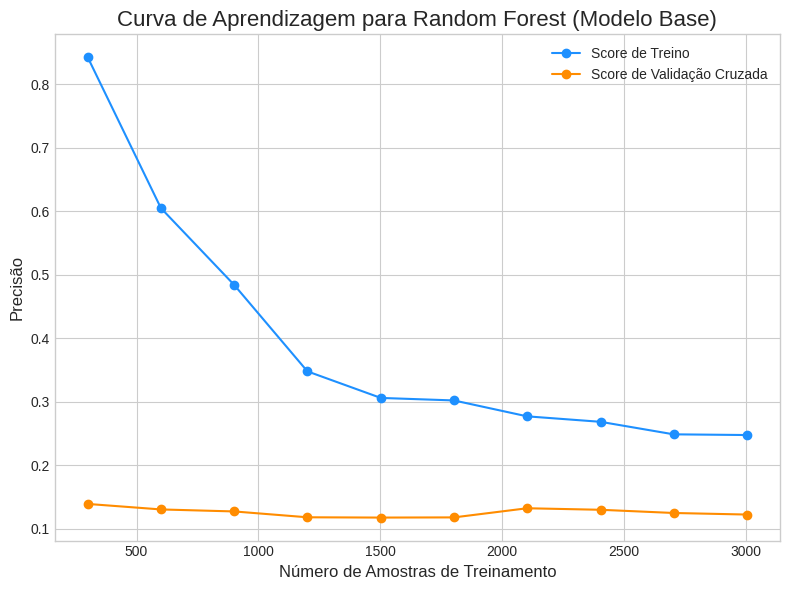

In [8]:
#======================================================================
# 2. DIAGNÓSTICO INICIAL (CURVA DE APRENDIZAGEM)
#======================================================================
# Vamos gerar a curva com um modelo base para entender o comportamento do aprendizado.
# Usamos o pipeline para garantir que o SMOTE seja aplicado corretamente na validação cruzada.
print("Gerando Curva de Aprendizagem para diagnóstico inicial...")
base_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)) # Um modelo padrão
])

train_sizes, train_scores, test_scores = learning_curve(
    estimator=base_pipeline,
    X=X_train, # Usamos apenas os dados de treino para o diagnóstico
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='precision' # Usando a mesma métrica principal do GridSearch
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='dodgerblue', label='Score de Treino')
plt.plot(train_sizes, test_scores_mean, 'o-', color='darkorange', label='Score de Validação Cruzada')
plt.title('Curva de Aprendizagem para Random Forest (Modelo Base)', fontsize=16)
plt.xlabel('Número de Amostras de Treinamento', fontsize=12)
plt.ylabel('Precisão', fontsize=12)
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig('diagnostico_curva_de_aprendizagem.png')
plt.show()

# Criação da pipeline para evitar vazamento de dados

In [9]:
#======================================================================
# 3. OTIMIZAÇÃO COM GRIDSEARCHCV E PIPELINE
#======================================================================
# Definir o pipeline final para otimização
pipeline_for_grid = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('data_checker', DataChecker()), # Nosso passo de verificação
    ('rf', RandomForestClassifier(random_state=42))
])

# Definir a grade de parâmetros
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2]
}

print("\nIniciando Grid Search para encontrar os melhores hiperparâmetros...")
grid_search = GridSearchCV(
    estimator=pipeline_for_grid,
    param_grid=param_grid,
    cv=5,
    scoring='precision',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("\nGrid Search concluído.")
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print("-" * 50)


Iniciando Grid Search para encontrar os melhores hiperparâmetros...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  > [PROVA SMOTE] Shape dos dados após SMOTE: (6860, 16)

Grid Search concluído.
Melhores parâmetros encontrados: {'rf__max_depth': 10, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
--------------------------------------------------


# Avaliação com Limiar de Decisão

  > [PROVA SMOTE] Shape dos dados após SMOTE: (1252, 16)


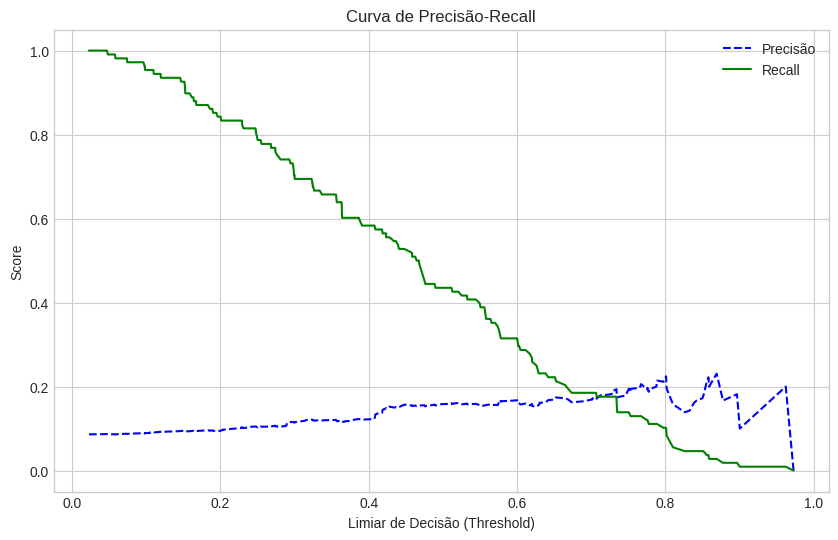


Relatório de Classificação com Novo Limiar:
              precision    recall  f1-score   support

           0       0.95      0.49      0.64      1144
           1       0.11      0.70      0.20       108

    accuracy                           0.50      1252
   macro avg       0.53      0.59      0.42      1252
weighted avg       0.87      0.50      0.60      1252


Matriz de Confusão Final:


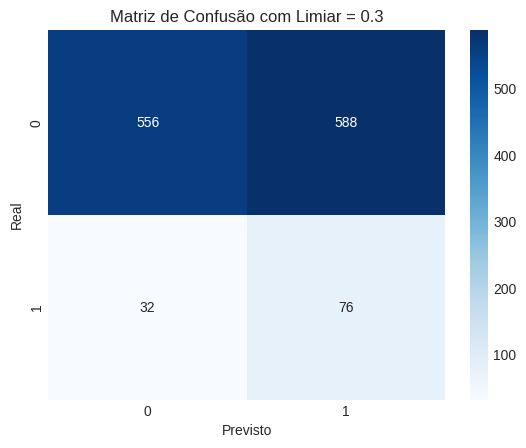

In [10]:
#======================================================================
# 4. AVALIAÇÃO DO MODELO FINAL
#======================================================================
final_model = grid_search.best_estimator_

# PASSO 1: Obtenha as probabilidades de previsão no conjunto de teste
# Precisamos da probabilidade da classe positiva (classe 1)
y_probs = final_model.predict_proba(X_test)[:, 1]

# PASSO 2: Calcule a curva de precisão-recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# PASSO 3: Plote a curva para escolher um bom limiar visualmente
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precisão')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.title('Curva de Precisão-Recall')
plt.xlabel('Limiar de Decisão (Threshold)')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

# PASSO 4: Aplique o novo limiar
novo_limiar = 0.3 # Exemplo: escolha um valor com base no gráfico acima

# Faça as novas previsões com base no limiar customizado
y_pred_novo_limiar = (y_probs >= novo_limiar).astype(int)

print("\nRelatório de Classificação com Novo Limiar:")
print(classification_report(y_test, y_pred_novo_limiar))


# Matriz de Confusão do Teste com o novo limiar
print("\nMatriz de Confusão Final:")
cm = confusion_matrix(y_test, y_pred_novo_limiar)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title(f"Matriz de Confusão com Limiar = {novo_limiar}")
plt.show()









Gerando gráfico de Precisão e Recall vs. Limiar por Classe...


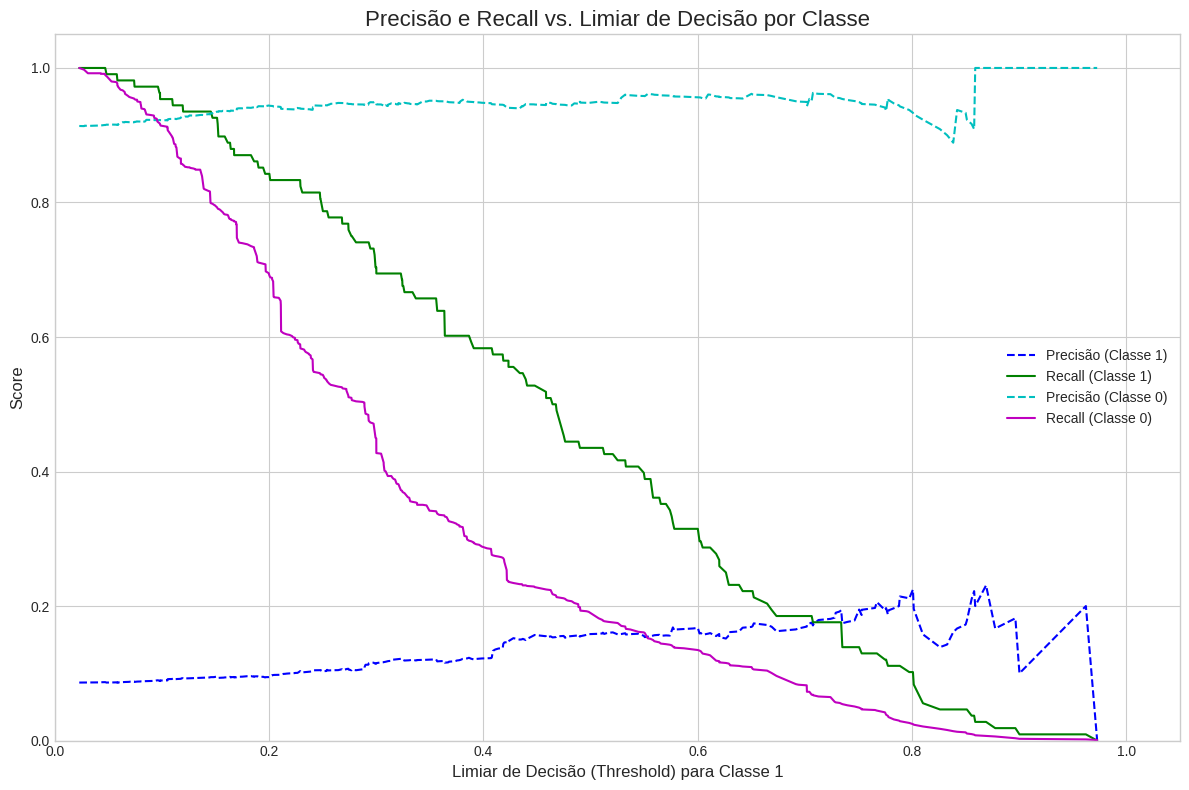

In [11]:
# prompt: Gere um gráfico de limiar de decisão que nos mostre a precisão e o recall das duas classes (0 e 1)

# Função para gerar o gráfico de limiar de decisão com precisão e recall por classe
def plot_precision_recall_threshold(y_test, y_probs):
    # Calcula a curva de precisão-recall para a classe positiva (classe 1)
    precisions_class1, recalls_class1, thresholds_class1 = precision_recall_curve(y_test, y_probs)

    # Para a classe negativa (classe 0), precisamos inverter os rótulos e as probabilidades
    y_test_inverted = 1 - y_test  # Inverte 0s para 1s e 1s para 0s
    y_probs_inverted = 1 - y_probs # A probabilidade de ser classe 0 é 1 - prob de ser classe 1

    # Calcula a curva de precisão-recall para a "classe positiva" invertida (que representa a classe 0 original)
    # Nota: A função precision_recall_curve espera que 1 seja a classe positiva.
    # Ao inverter, calculamos PR para a classe 0 original como se ela fosse a positiva.
    precisions_class0, recalls_class0, thresholds_class0 = precision_recall_curve(y_test_inverted, y_probs_inverted)

    plt.figure(figsize=(12, 8))

    # Plota a precisão e recall para a Classe 1 (Situação de Trabalho = 1)
    plt.plot(thresholds_class1, precisions_class1[:-1], 'b--', label='Precisão (Classe 1)')
    plt.plot(thresholds_class1, recalls_class1[:-1], 'g-', label='Recall (Classe 1)')

    # Plota a precisão e recall para a Classe 0 (Situação de Trabalho = 0)
    # Precisamos ajustar os thresholds para a classe 0. Se o threshold para classe 1 é `t`,
    # então prevemos 0 se prob(classe 1) < t, o que significa prob(classe 0) > 1-t.
    # Portanto, o threshold equivalente para a classe 0 é `1 - threshold_class1`.
    # Usamos thresholds_class1 aqui para manter o eixo x como o limiar da classe 1.
    plt.plot(thresholds_class1, precisions_class0[:-1], 'c--', label='Precisão (Classe 0)') # Usando thresholds_class1
    plt.plot(thresholds_class1, recalls_class0[:-1], 'm-', label='Recall (Classe 0)')      # Usando thresholds_class1


    plt.title('Precisão e Recall vs. Limiar de Decisão por Classe', fontsize=16)
    plt.xlabel('Limiar de Decisão (Threshold) para Classe 1', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True)
    plt.ylim([0, 1.05]) # Limitar o eixo y entre 0 e 1
    plt.xlim([0, 1.05]) # Limitar o eixo x entre 0 e 1
    plt.tight_layout()
    plt.savefig('precisao_recall_limiar_por_classe.png')
    plt.show()

# Chamar a função com os dados de teste e as probabilidades do modelo final
print("\nGerando gráfico de Precisão e Recall vs. Limiar por Classe...")
plot_precision_recall_threshold(y_test, y_probs)



# Plotagem da matriz de confusão

Avaliando o modelo final no conjunto de treino...
  > [PROVA SMOTE] Shape dos dados após SMOTE: (3756, 16)

Relatório de Classificação no Conjunto de Treino:
                 precision    recall  f1-score   support

   Empregado(a)       0.96      0.80      0.87      3430
Desempregado(a)       0.23      0.63      0.34       326

       accuracy                           0.78      3756
      macro avg       0.59      0.72      0.61      3756
   weighted avg       0.90      0.78      0.83      3756



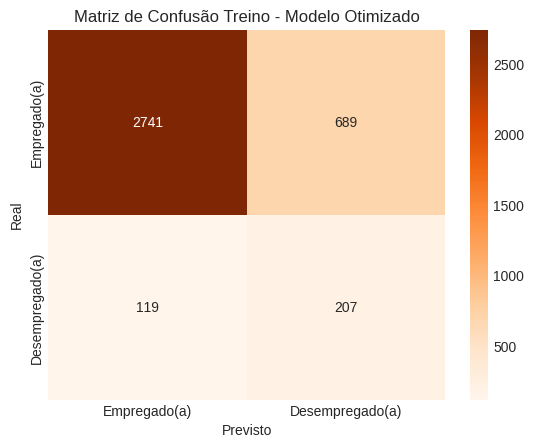

Avaliando o modelo final no conjunto de teste...
  > [PROVA SMOTE] Shape dos dados após SMOTE: (1252, 16)

Relatório de Classificação no Conjunto de Teste:
                 precision    recall  f1-score   support

   Empregado(a)       0.95      0.49      0.64      1144
Desempregado(a)       0.11      0.70      0.20       108

       accuracy                           0.50      1252
      macro avg       0.53      0.59      0.42      1252
   weighted avg       0.87      0.50      0.60      1252



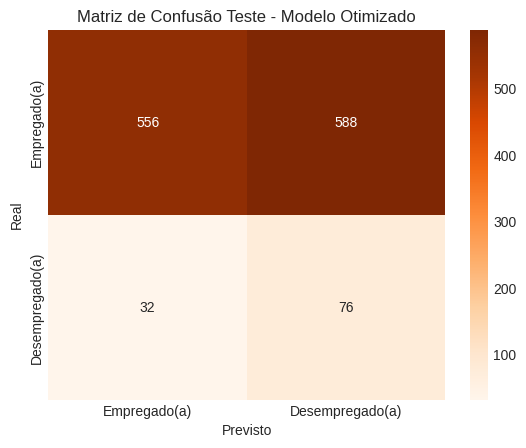

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Avaliação no conjunto de treino
print("Avaliando o modelo final no conjunto de treino...")
y_pred_train = final_model.predict(X_train)

print("\nRelatório de Classificação no Conjunto de Treino:")
print(classification_report(y_train, y_pred_train, target_names=["Empregado(a)", "Desempregado(a)"]))

# Matriz de Confusão do Treino
cm_train = confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Oranges',
            xticklabels=["Empregado(a)", "Desempregado(a)"],
            yticklabels=["Empregado(a)", "Desempregado(a)"])
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão Treino - Modelo Otimizado")
plt.show()

# Avaliação no conjunto de teste
print("Avaliando o modelo final no conjunto de teste...")
y_pred_test = final_model.predict(X_test)

print("\nRelatório de Classificação no Conjunto de Teste:")
print(classification_report(y_test, y_pred_novo_limiar, target_names=["Empregado(a)", "Desempregado(a)"]))

# Matriz de Confusão do Teste
cm_test = confusion_matrix(y_test, y_pred_novo_limiar)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=["Empregado(a)", "Desempregado(a)"],
            yticklabels=["Empregado(a)", "Desempregado(a)"])
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão Teste - Modelo Otimizado")
plt.show()


# Feature Importance


Extraindo a importância das features do modelo final...
As 20 Features Mais Importantes (extraídas do Pipeline):
                           Feature  Importance
2                  Nível de Ensino    0.343097
1   Área de formação em tecnologia    0.080329
0                           Genero    0.067670
10        Região onde mora_Sudeste    0.053555
11            Região onde mora_Sul    0.053079
12      Faixa Etária_Faixa_1_Idade    0.052129
13      Faixa Etária_Faixa_2_Idade    0.049612
5             Cor/raca/etnia_Parda    0.049575
14      Faixa Etária_Faixa_3_Idade    0.048135
3            Cor/raca/etnia_Branca    0.047355
15      Faixa Etária_Faixa_4_Idade    0.042686
7    Região onde mora_Centro-oeste    0.036167
8        Região onde mora_Nordeste    0.034423
6             Cor/raca/etnia_Preta    0.029762
9           Região onde mora_Norte    0.011566
4             Cor/raca/etnia_Outra    0.000859


/tmp/ipython-input-13-4254605434.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')


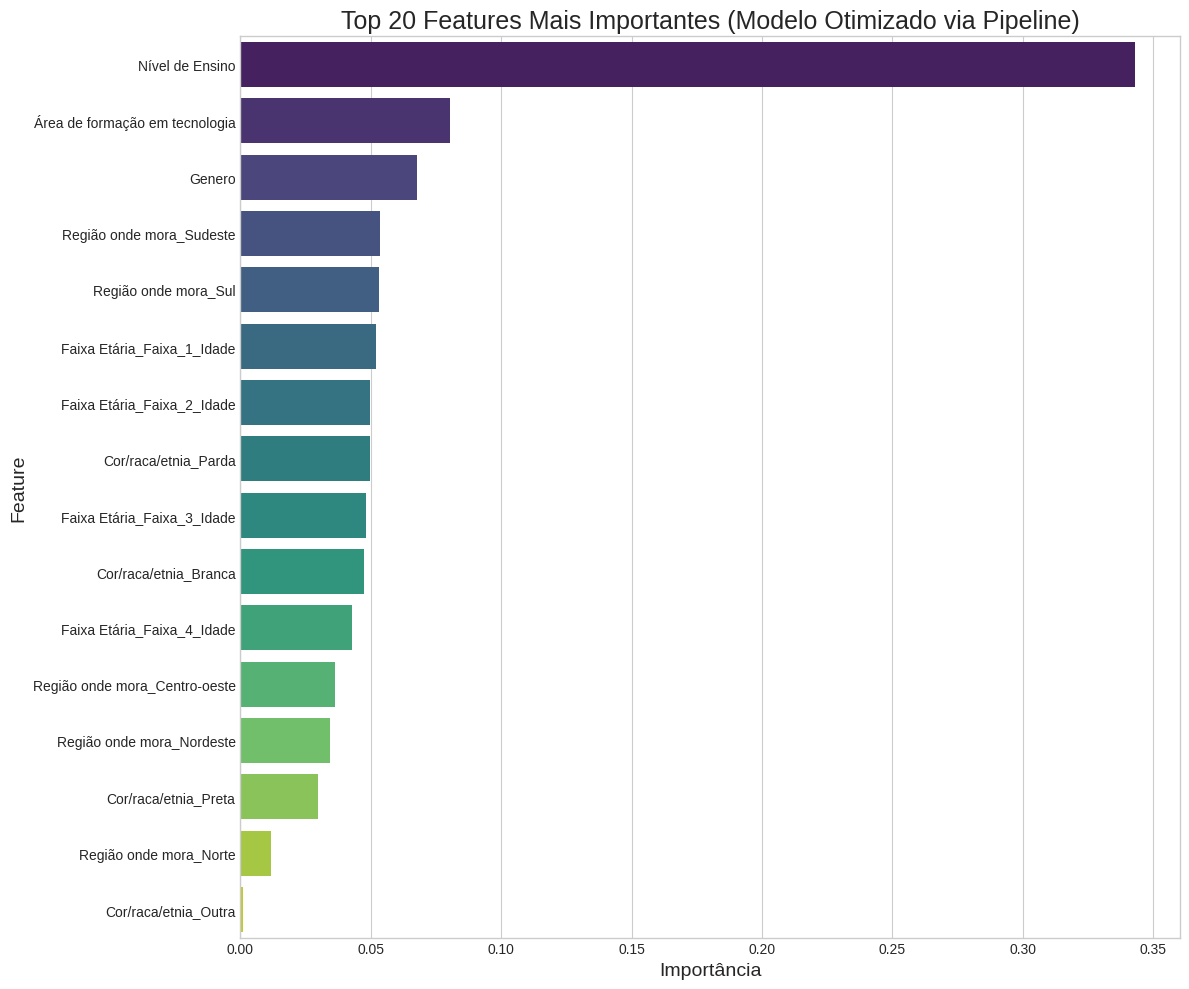

In [13]:
#======================================================================
# 5. ANÁLISE DE IMPORTÂNCIA DAS FEATURES
#======================================================================
print("\nExtraindo a importância das features do modelo final...")
# Acessar o passo do modelo RandomForest DENTRO do pipeline
rf_step = final_model.named_steps['rf']
importances = rf_step.feature_importances_

feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

print("As 20 Features Mais Importantes (extraídas do Pipeline):")
print(top_20_features)

# Gerar o gráfico
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')
plt.title('Top 20 Features Mais Importantes (Modelo Otimizado via Pipeline)', fontsize=18)
plt.xlabel('Importância', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.tight_layout()
plt.show()